# EDA IMERG trên Google Drive

Notebook này **không tải dữ liệu**. Nó mở file NetCDF IMERG đã có trên Google Drive để kiểm tra:

1. Data integrity: thời gian, timestep thiếu/trùng/dư, shape, lat/lon và NaN.
2. Phân bố lượng mưa: thống kê, histogram, tỷ lệ không mưa/có mưa và nhóm cường độ.
3. Không gian: mean map, max map và các frame mẫu.
4. Thời gian: rainfall theo timestep, ngày/tháng mưa nhiều và seasonality.
5. Nowcasting: continuity giữa 6 frame lịch sử và 4 frame tương lai.

Đơn vị dữ liệu kỳ vọng: `mm/30 min`.

In [1]:
# Chạy cell này đầu tiên.
import sys
import subprocess
from pathlib import Path

if "google.colab" in sys.modules:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "xarray", "netCDF4", "pandas", "numpy", "matplotlib", "seaborn",
    ])

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

try:
    from google.colab import drive

    drive.mount("/content/drive")
    IN_COLAB = True
    DRIVE_ROOT = Path("/content/drive/MyDrive")
except ImportError:
    IN_COLAB = False
    DRIVE_ROOT = Path.cwd()

PROJECT_DIR = DRIVE_ROOT / "Rainfall_Nowcasting" / "IMERG"
DEFAULT_NETCDF = PROJECT_DIR / "data" / "imerg_vietnam" / "imerg_vietnam_2023_2024.nc"
FIG_DIR = PROJECT_DIR / "figures_eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Running in Colab: {IN_COLAB}")
print(f"Expected NetCDF: {DEFAULT_NETCDF}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running in Colab: True
Expected NetCDF: /content/drive/MyDrive/Rainfall_Nowcasting/IMERG/data/imerg_vietnam/imerg_vietnam_2023_2024.nc


## 1. Mở file NetCDF và xác định khoảng thời gian

Cell này tìm file chính trên Drive. Nếu không tồn tại, nó liệt kê các file `.nc` để chọn đúng đường dẫn.

In [2]:
NETCDF_PATH = DEFAULT_NETCDF
if not NETCDF_PATH.exists():
    candidates = sorted(PROJECT_DIR.rglob("*.nc"))
    print("Không tìm thấy file mặc định.")
    print("Các file NetCDF đang có:")
    for candidate in candidates:
        print(candidate)
    raise FileNotFoundError("Hãy sửa NETCDF_PATH thành đường dẫn file NetCDF trên Drive.")

with xr.open_dataset(NETCDF_PATH) as dataset:
    print(dataset)
    variable_names = list(dataset.data_vars)
    rainfall_name = "rainfall" if "rainfall" in variable_names else variable_names[0]
    rain = dataset[rainfall_name].load()

if "time" not in rain.dims:
    raise ValueError(f"Biến {rainfall_name!r} không có dimension time: {rain.dims}")

rain = rain.sortby("time")
actual_time = pd.DatetimeIndex(pd.to_datetime(rain.time.values))
print(f"Loaded variable: {rainfall_name}")
print(f"File: {NETCDF_PATH}")
print(f"Date range: {actual_time.min()} -> {actual_time.max()}")
print(f"Shape: {rain.shape}")
print(f"Dimensions: {rain.dims}")
print(f"Units: {rain.attrs.get('units', 'unknown')}")

<xarray.Dataset> Size: 2GB
Dimensions:   (time: 35089, lat: 165, lon: 80)
Coordinates:
  * time      (time) datetime64[ns] 281kB 2023-01-01 ... 2025-01-01
  * lat       (lat) float32 660B 8.05 8.15 8.25 8.35 ... 24.15 24.25 24.35 24.45
  * lon       (lon) float32 320B 102.0 102.2 102.2 102.3 ... 109.8 109.8 109.9
Data variables:
    rainfall  (time, lat, lon) float32 2GB ...
Attributes:
    title:    IMERG rainfall cropped to Vietnam
Loaded variable: rainfall
File: /content/drive/MyDrive/Rainfall_Nowcasting/IMERG/data/imerg_vietnam/imerg_vietnam_2023_2024.nc
Date range: 2023-01-01 00:00:00 -> 2025-01-01 00:00:00
Shape: (35089, 165, 80)
Dimensions: ('time', 'lat', 'lon')
Units: mm/30 min


## 2. Data integrity

Kiểm tra số timestep kỳ vọng trong khoảng dữ liệu thực tế, timestep thiếu/trùng/dư, khoảng cách thời gian, tọa độ, NaN/fill value và giá trị bất thường.

In [3]:
expected_time = pd.date_range(
    actual_time.min().floor("30min"),
    actual_time.max().floor("30min"),
    freq="30min",
)
missing_time = expected_time.difference(actual_time)
extra_time = actual_time.difference(expected_time)
duplicate_time = actual_time[actual_time.duplicated()]
intervals = actual_time.to_series().diff().dropna()

values = rain.values
finite_values = values[np.isfinite(values)]
fill_like_count = int(np.sum((finite_values < 0) | (finite_values > 500)))
nan_fraction = float(np.isnan(values).mean())

integrity = pd.Series({
    "file_start": actual_time.min(),
    "file_end": actual_time.max(),
    "actual_timesteps": len(actual_time),
    "expected_timesteps_in_file_range": len(expected_time),
    "missing_timesteps": len(missing_time),
    "extra_timesteps": len(extra_time),
    "duplicate_timesteps": len(duplicate_time),
    "minimum_interval": intervals.min() if len(intervals) else pd.NaT,
    "maximum_interval": intervals.max() if len(intervals) else pd.NaT,
    "shape_time_lat_lon": tuple(rain.shape),
    "nan_fraction": nan_fraction,
    "negative_or_implausible_values": fill_like_count,
    "latitude_min": float(rain.lat.min()) if "lat" in rain.coords else np.nan,
    "latitude_max": float(rain.lat.max()) if "lat" in rain.coords else np.nan,
    "longitude_min": float(rain.lon.min()) if "lon" in rain.coords else np.nan,
    "longitude_max": float(rain.lon.max()) if "lon" in rain.coords else np.nan,
})
print(integrity)

if len(missing_time):
    print("First missing timesteps:", missing_time[:20].tolist())
if len(extra_time):
    print("Extra timesteps:", extra_time[:20].tolist())
if len(duplicate_time):
    print("Duplicate timesteps:", duplicate_time[:20].tolist())

if len(intervals):
    print("Interval counts:")
    print(intervals.value_counts().sort_index())

file_start                          2023-01-01 00:00:00
file_end                            2025-01-01 00:00:00
actual_timesteps                                  35089
expected_timesteps_in_file_range                  35089
missing_timesteps                                     0
extra_timesteps                                       0
duplicate_timesteps                                   0
minimum_interval                        0 days 00:30:00
maximum_interval                        0 days 00:30:00
shape_time_lat_lon                     (35089, 165, 80)
nan_fraction                                        0.0
negative_or_implausible_values                        0
latitude_min                                       8.05
latitude_max                                  24.449999
longitude_min                                102.049995
longitude_max                                109.949997
dtype: object
Interval counts:
0 days 00:30:00    35088
Name: count, dtype: int64


## 3. Phân bố lượng mưa

Thống kê trên toàn bộ pixel hợp lệ. Ngưỡng phân loại là lượng mưa mỗi 30 phút: không mưa `< 0.1`, nhẹ `0.1-2.5`, vừa `2.5-10`, lớn `10-50`, cực đoan `>= 50` mm/30 min.

count            4.631748e+08
min              0.000000e+00
max              4.839500e+01
mean             1.101986e-01
median_sample    0.000000e+00
p90_sample       3.500000e-02
p95_sample       3.100000e-01
p99_sample       1.220000e+00
p99_9_sample     3.540005e+00
nan_fraction     0.000000e+00
dtype: float64
             pixels    percent
no rain   412215323  88.997787
light      46489196  10.037074
moderate    4267024   0.921256
heavy        203257   0.043883
extreme           0   0.000000


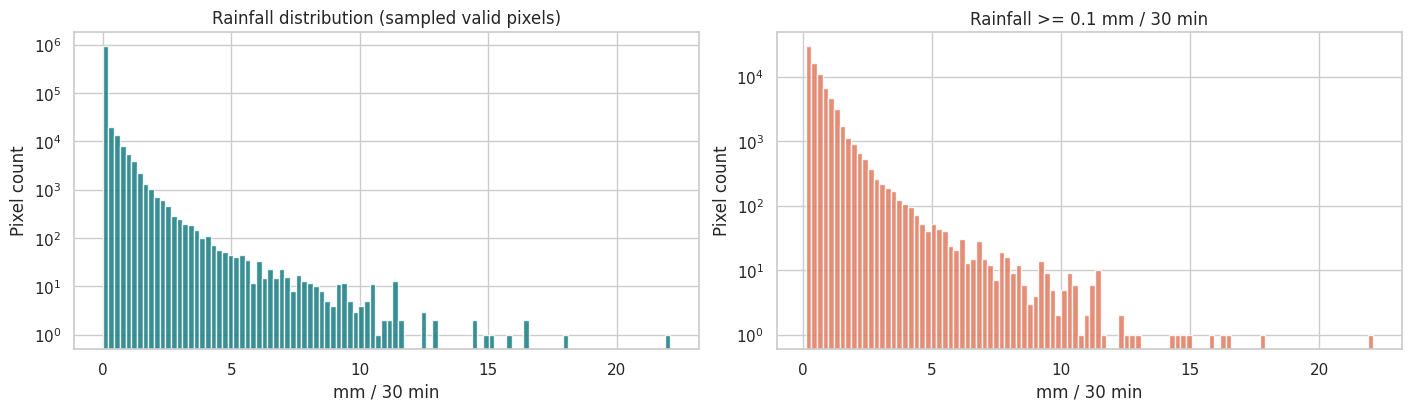

In [7]:
# Process theo chunk de tranh tao nhieu ban sao lon trong RAM.
CHUNK_TIMESTEPS = 256
MAX_SAMPLE_VALUES = 1_000_000

value_count = 0
value_sum = 0.0
value_min = np.inf
value_max = -np.inf
nan_count = 0
class_counts = np.zeros(5, dtype=np.int64)
sample_parts = []

for start in range(0, rain.sizes["time"], CHUNK_TIMESTEPS):
    chunk = rain.isel(time=slice(start, start + CHUNK_TIMESTEPS)).values
    nan_count += int(np.isnan(chunk).sum())
    finite = chunk[np.isfinite(chunk)]
    finite = finite[finite >= 0]
    if finite.size == 0:
        continue

    value_count += finite.size
    value_sum += float(finite.sum(dtype=np.float64))
    value_min = min(value_min, float(finite.min()))
    value_max = max(value_max, float(finite.max()))

    class_counts += np.array([
        np.count_nonzero(finite < 0.1),
        np.count_nonzero((finite >= 0.1) & (finite < 2.5)),
        np.count_nonzero((finite >= 2.5) & (finite < 10)),
        np.count_nonzero((finite >= 10) & (finite < 50)),
        np.count_nonzero(finite >= 50),
    ])

    remaining = MAX_SAMPLE_VALUES - sum(part.size for part in sample_parts)
    if remaining > 0:
        step = max(1, finite.size // remaining)
        sample_parts.append(finite[::step][:remaining])

if value_count == 0:
    raise ValueError("Không có pixel rainfall hợp lệ để phân tích.")

sample_values = np.concatenate(sample_parts)[:MAX_SAMPLE_VALUES]
percentiles = np.percentile(sample_values, [50, 90, 95, 99, 99.9])
summary = pd.Series({
    "count": value_count,
    "min": value_min,
    "max": value_max,
    "mean": value_sum / value_count,
    "median_sample": percentiles[0],
    "p90_sample": percentiles[1],
    "p95_sample": percentiles[2],
    "p99_sample": percentiles[3],
    "p99_9_sample": percentiles[4],
    "nan_fraction": nan_count / rain.size,
})
print(summary)

labels = ["no rain", "light", "moderate", "heavy", "extreme"]
class_table = pd.DataFrame({
    "pixels": class_counts,
    "percent": class_counts / value_count * 100,
}, index=labels)
print(class_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
axes[0].hist(sample_values, bins=100, color="#167c80", alpha=0.85)
axes[0].set_title("Rainfall distribution (sampled valid pixels)")
axes[0].set_xlabel("mm / 30 min")
axes[0].set_ylabel("Pixel count")
axes[0].set_yscale("log")

wet_values = sample_values[sample_values >= 0.1]
axes[1].hist(wet_values, bins=100, color="#e07a5f", alpha=0.85)
axes[1].set_title("Rainfall >= 0.1 mm / 30 min")
axes[1].set_xlabel("mm / 30 min")
axes[1].set_ylabel("Pixel count")
axes[1].set_yscale("log")

plt.savefig(FIG_DIR / "rainfall_distribution.png", dpi=160)
plt.show()
del sample_values, sample_parts

## 4. Phân tích không gian

Mean map cho vùng mưa thường xuyên, max map cho cực trị, và các frame cách đều trong file để kiểm tra pattern không gian.

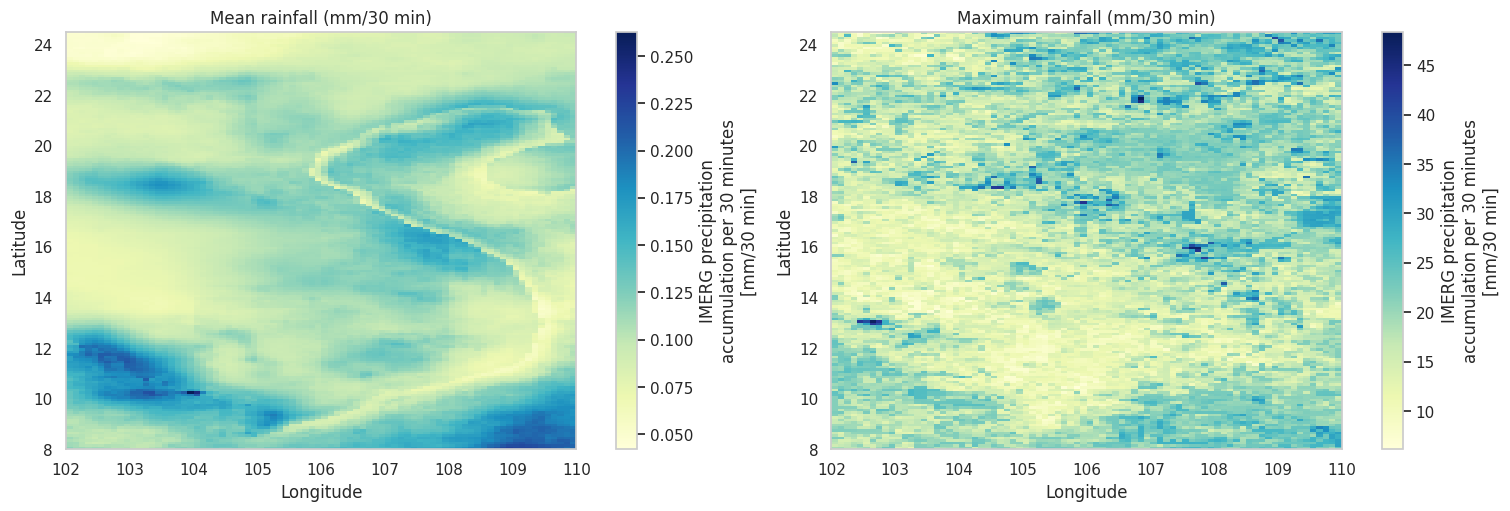

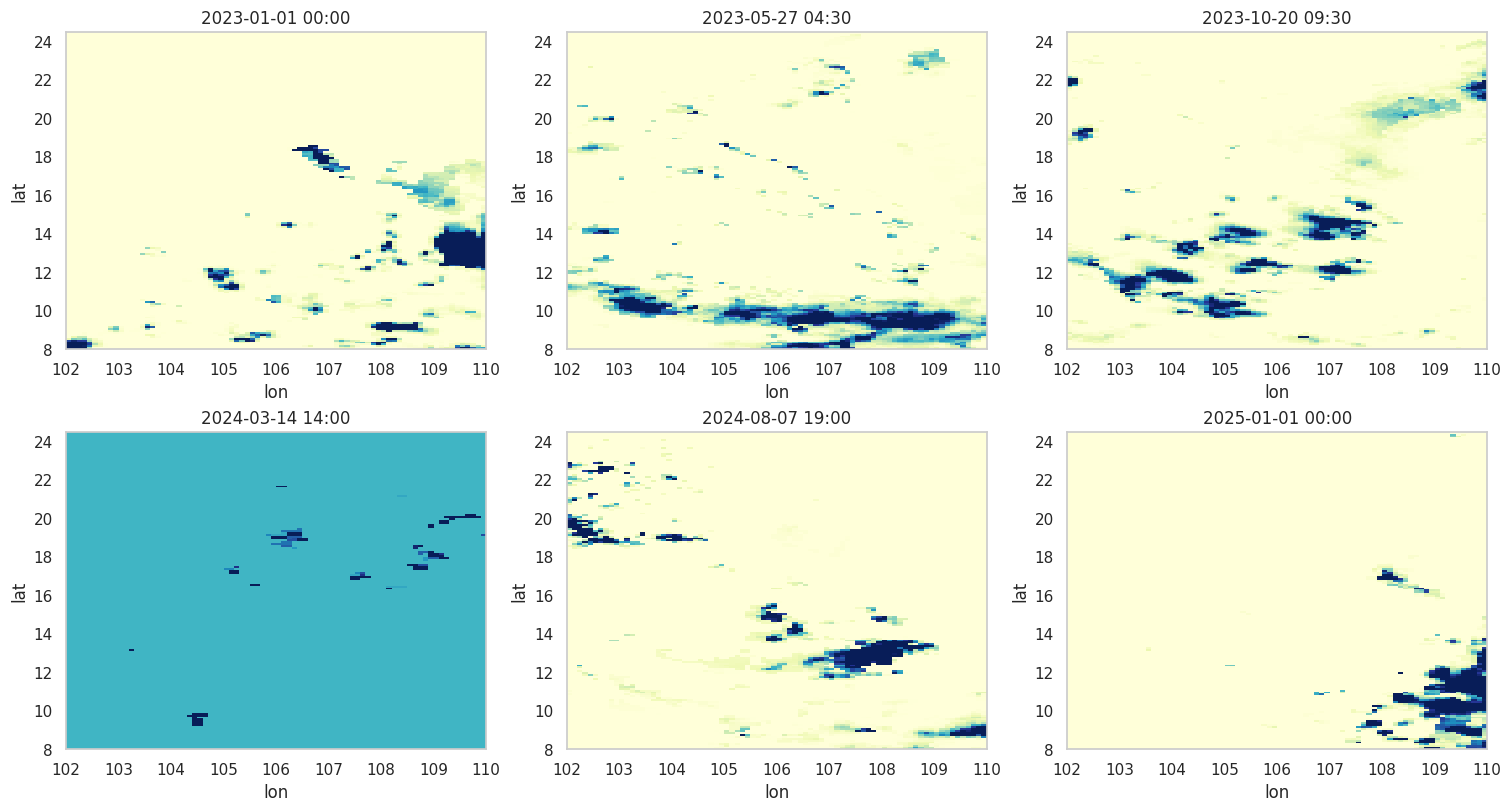

In [4]:
mean_map = rain.mean("time", skipna=True)
max_map = rain.max("time", skipna=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
for axis, field, title in zip(
    axes,
    [mean_map, max_map],
    ["Mean rainfall", "Maximum rainfall"],
):
    field.plot(ax=axis, cmap="YlGnBu", add_colorbar=True)
    axis.set_title(f"{title} ({rain.attrs.get('units', 'rainfall')})")
    axis.set_xlabel("Longitude")
    axis.set_ylabel("Latitude")
plt.savefig(FIG_DIR / "rainfall_mean_max_maps.png", dpi=160)
plt.show()

sample_indices = np.linspace(0, rain.sizes["time"] - 1, 6, dtype=int)
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
for axis, index in zip(axes.flat, sample_indices):
    rain.isel(time=index).plot(
        ax=axis, cmap="YlGnBu", vmin=0, robust=True, add_colorbar=False
    )
    timestamp = pd.Timestamp(rain.time.values[index]).strftime("%Y-%m-%d %H:%M")
    axis.set_title(timestamp)
plt.savefig(FIG_DIR / "rainfall_sample_frames.png", dpi=160)
plt.show()

## 5. Phân tích thời gian

Tính rainfall trung bình không gian theo mỗi 30 phút, tổng theo ngày/tháng và liệt kê các thời điểm mưa nhiều nhất.

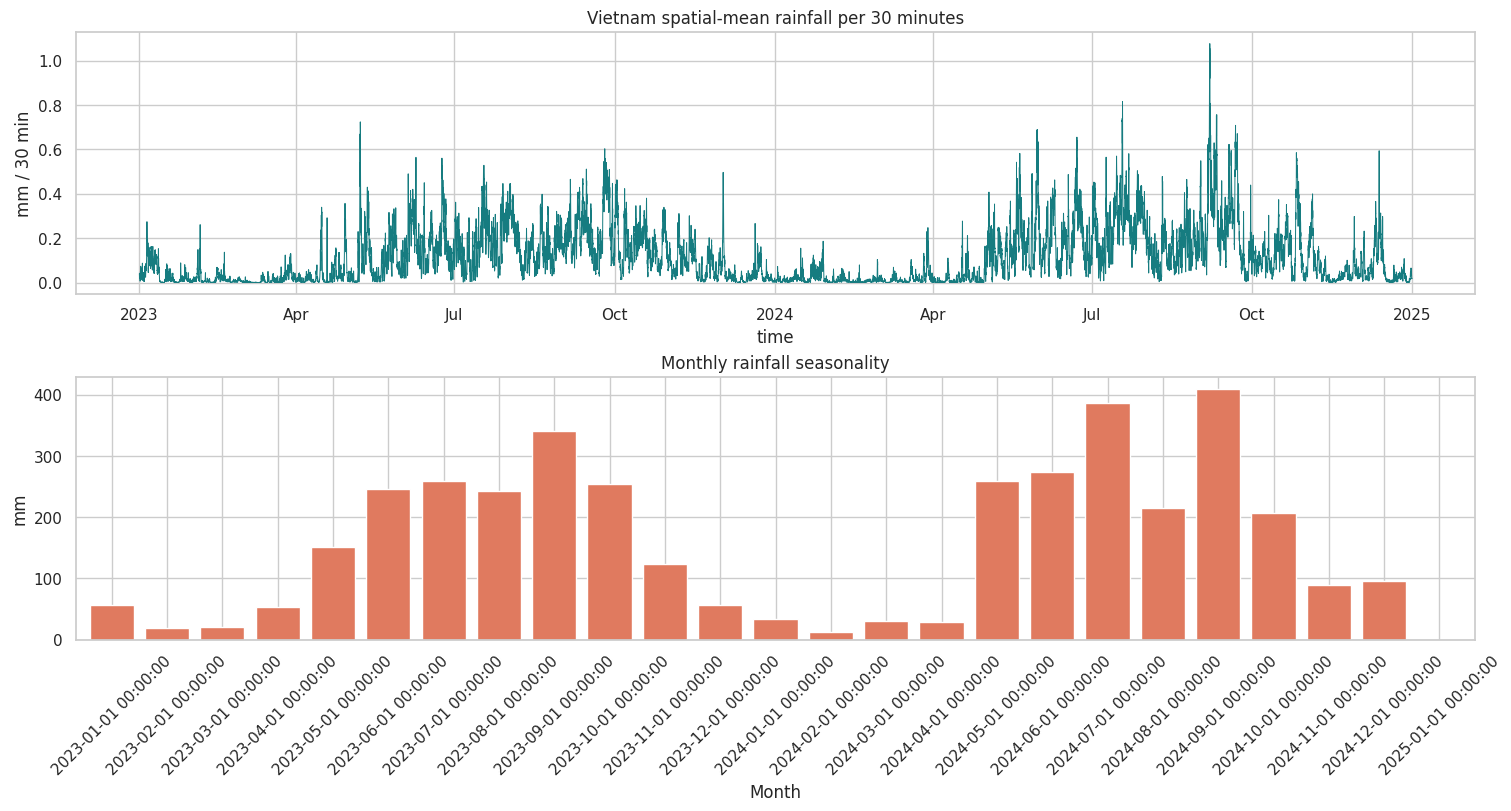

Wettest 10 half-hour timesteps:
time
2024-09-06 22:30:00    1.077185
2024-09-06 21:00:00    1.056008
2024-09-06 23:30:00    1.033609
2024-09-07 00:00:00    1.033499
2024-09-06 23:00:00    1.026262
2024-09-06 20:00:00    1.001491
2024-09-06 20:30:00    0.989942
2024-09-06 19:30:00    0.933059
2024-09-06 21:30:00    0.931648
2024-09-06 19:00:00    0.927620
Name: rainfall, dtype: float32
Wettest 10 days:
time
2024-09-06    30.699953
2024-09-07    27.291969
2024-09-22    26.892578
2024-09-10    26.586695
2024-07-18    24.224518
2023-09-25    23.939976
2023-09-26    22.382126
2024-09-21    22.111511
2024-06-22    22.099920
2024-05-30    21.054838
Name: rainfall, dtype: float32


In [5]:
spatial_mean = rain.mean(dim=("lat", "lon"), skipna=True)
spatial_max = rain.max(dim=("lat", "lon"), skipna=True)
daily_total = rain.resample(time="1D").sum(skipna=True).mean(dim=("lat", "lon"), skipna=True)
monthly_total = daily_total.resample(time="1MS").sum(skipna=True)

fig, axes = plt.subplots(2, 1, figsize=(15, 8), constrained_layout=True)
spatial_mean.plot(ax=axes[0], color="#167c80", linewidth=0.7)
axes[0].set_title("Vietnam spatial-mean rainfall per 30 minutes")
axes[0].set_ylabel("mm / 30 min")
monthly_total.to_series().plot.bar(ax=axes[1], color="#e07a5f", width=0.8)
axes[1].set_title("Monthly rainfall seasonality")
axes[1].set_ylabel("mm")
axes[1].set_xlabel("Month")
axes[1].tick_params(axis="x", rotation=45)
plt.savefig(FIG_DIR / "rainfall_time_series_seasonality.png", dpi=160)
plt.show()

print("Wettest 10 half-hour timesteps:")
print(spatial_mean.sortby(spatial_mean, ascending=False).head(10).to_pandas())
print("Wettest 10 days:")
print(daily_total.sortby(daily_total, ascending=False).head(10).to_pandas())

## 6. Chuỗi nowcasting và continuity

Một cửa sổ gồm 6 frame lịch sử (`t-150` đến `t`) và 4 frame tương lai (`t+30` đến `t+120`). Cell này kiểm tra timestamp liên tiếp, vẽ 10 frame và tính spatial correlation giữa các frame liền kề.

Window: 2024-01-01 09:30:00 -> 2024-01-01 14:00:00
Window intervals: <TimedeltaArray>
['0 days 00:30:00']
Length: 1, dtype: timedelta64[ns]
Input history: [Timestamp('2024-01-01 09:30:00'), Timestamp('2024-01-01 10:00:00'), Timestamp('2024-01-01 10:30:00'), Timestamp('2024-01-01 11:00:00'), Timestamp('2024-01-01 11:30:00'), Timestamp('2024-01-01 12:00:00')]
Forecast targets: [Timestamp('2024-01-01 12:30:00'), Timestamp('2024-01-01 13:00:00'), Timestamp('2024-01-01 13:30:00'), Timestamp('2024-01-01 14:00:00')]


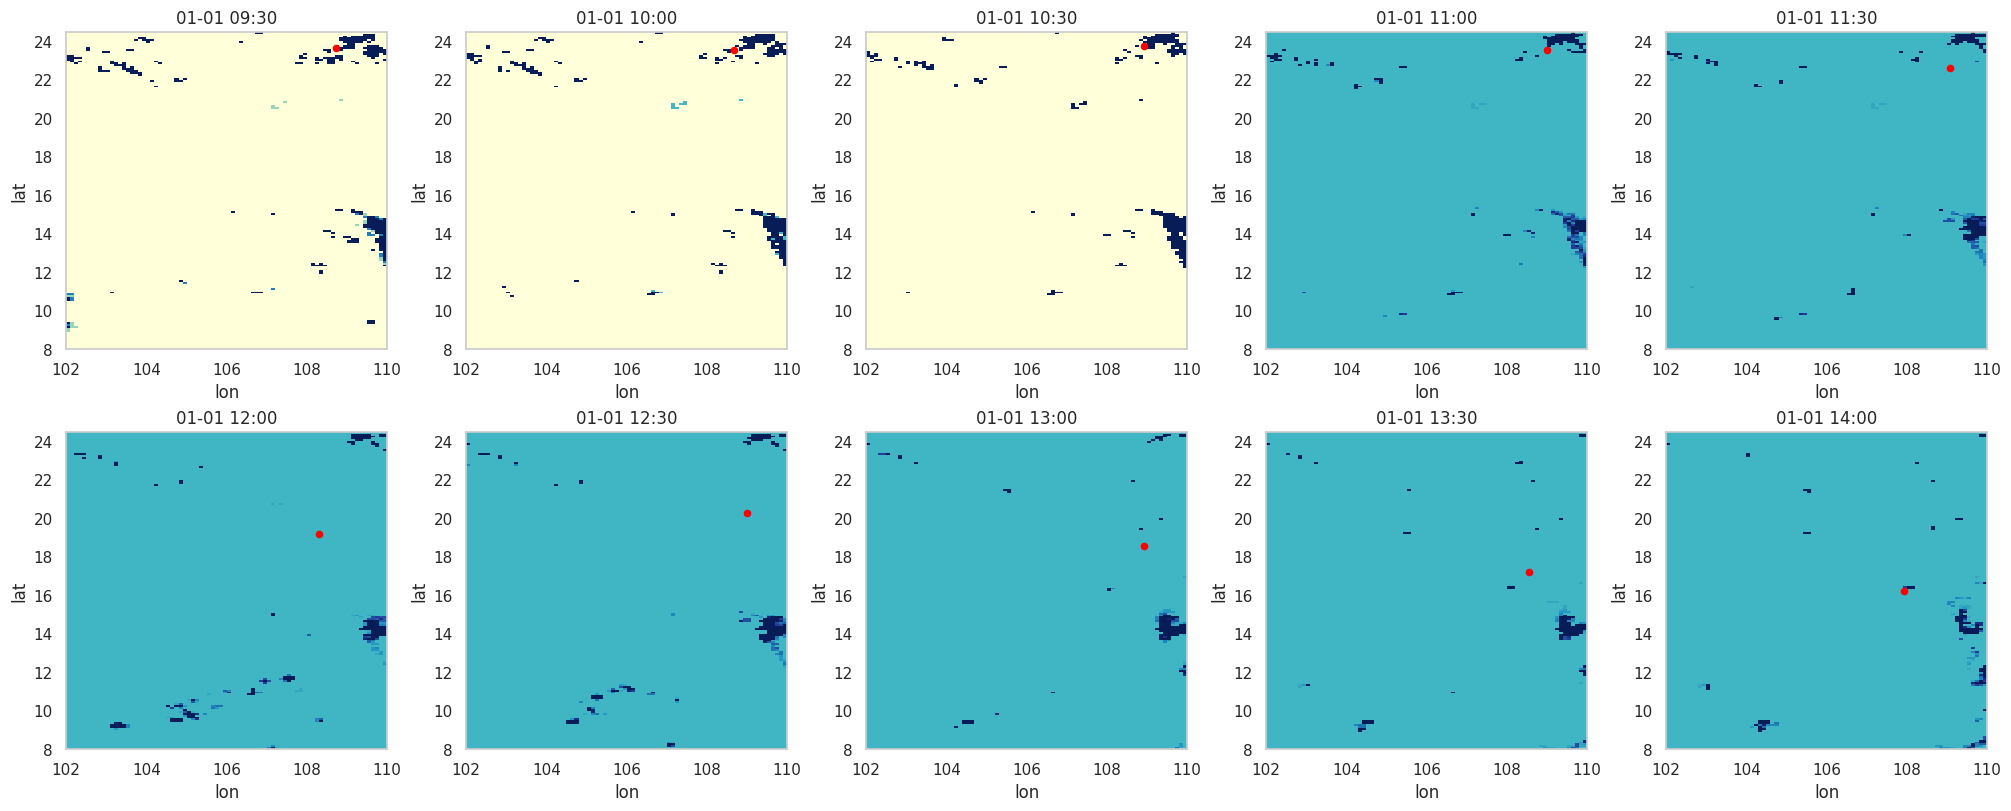

                     centroid_lat  centroid_lon  rainy_pixel_count
time                                                              
2024-01-01 09:30:00     23.666195    108.716003                158
2024-01-01 10:00:00     23.557468    108.670708                153
2024-01-01 10:30:00     23.748308    108.911758                125
2024-01-01 11:00:00     23.533688    109.001190                101
2024-01-01 11:30:00     22.591242    109.070694                103
2024-01-01 12:00:00     19.170650    108.292503                 97
2024-01-01 12:30:00     20.264530    108.998680                102
2024-01-01 13:00:00     18.535198    108.922577                 78
2024-01-01 13:30:00     17.183668    108.543091                 72
2024-01-01 14:00:00     16.223276    107.928413                 64


,from,to,spatial_correlation
0,2024-01-01 09:30:00,2024-01-01 10:00:00,0.969537
1,2024-01-01 10:00:00,2024-01-01 10:30:00,0.938192
2,2024-01-01 10:30:00,2024-01-01 11:00:00,0.909772
3,2024-01-01 11:00:00,2024-01-01 11:30:00,0.909898
4,2024-01-01 11:30:00,2024-01-01 12:00:00,0.585246
5,2024-01-01 12:00:00,2024-01-01 12:30:00,0.781169
6,2024-01-01 12:30:00,2024-01-01 13:00:00,0.769631
7,2024-01-01 13:00:00,2024-01-01 13:30:00,0.751472
8,2024-01-01 13:30:00,2024-01-01 14:00:00,0.780895


In [6]:
HISTORY_STEPS = 6
FORECAST_STEPS = 4
WINDOW_SIZE = HISTORY_STEPS + FORECAST_STEPS
RAIN_THRESHOLD = 0.1

# Chọn một cửa sổ ở giữa file; có thể thay bằng timestamp cụ thể.
target_time = actual_time[len(actual_time) // 2]
target_index = int(np.argmin(np.abs(actual_time - target_time)))
start_index = target_index - HISTORY_STEPS + 1
end_index = start_index + WINDOW_SIZE

if start_index < 0 or end_index > len(actual_time):
    raise ValueError("Không đủ frame cho cửa sổ nowcasting 6+4.")

window_times = actual_time[start_index:end_index]
window_intervals = window_times.to_series().diff().dropna()
print(f"Window: {window_times[0]} -> {window_times[-1]}")
print(f"Window intervals: {window_intervals.unique()}")
print("Input history:", window_times[:HISTORY_STEPS].tolist())
print("Forecast targets:", window_times[HISTORY_STEPS:].tolist())

fig, axes = plt.subplots(2, 5, figsize=(20, 8), constrained_layout=True)
centroids = []
for axis, index in zip(axes.flat, range(start_index, end_index)):
    frame = rain.isel(time=index)
    mask = frame >= RAIN_THRESHOLD
    count = int(mask.sum(skipna=True))
    weights = frame.where(mask).fillna(0)
    total = float(weights.sum())
    if total > 0:
        centroid_lat = float((weights * frame.lat).sum() / total)
        centroid_lon = float((weights * frame.lon).sum() / total)
    else:
        centroid_lat = np.nan
        centroid_lon = np.nan
    centroids.append((actual_time[index], centroid_lat, centroid_lon, count))
    frame.plot(ax=axis, cmap="YlGnBu", vmin=0, robust=True, add_colorbar=False)
    axis.set_title(actual_time[index].strftime("%m-%d %H:%M"))
    if np.isfinite(centroid_lat):
        axis.scatter([centroid_lon], [centroid_lat], color="red", s=20)

plt.savefig(FIG_DIR / "nowcasting_6_history_4_targets.png", dpi=160)
plt.show()

centroid_table = pd.DataFrame(
    centroids,
    columns=["time", "centroid_lat", "centroid_lon", "rainy_pixel_count"],
).set_index("time")
print(centroid_table)

correlations = []
for left, right in zip(range(start_index, end_index - 1), range(start_index + 1, end_index)):
    first = rain.isel(time=left).values.ravel()
    second = rain.isel(time=right).values.ravel()
    valid = np.isfinite(first) & np.isfinite(second)
    correlation = np.corrcoef(first[valid], second[valid])[0, 1] if valid.sum() > 2 else np.nan
    correlations.append({
        "from": actual_time[left],
        "to": actual_time[right],
        "spatial_correlation": correlation,
    })

frame_correlations = pd.DataFrame(correlations)
frame_correlations

Requested Vietnam crop bbox: {'west': 102.0, 'south': 8.0, 'east': 110.0, 'north': 24.5}
Observed NetCDF coordinate bounds: {'latitude_min': 8.050000190734863, 'latitude_max': 24.44999885559082, 'longitude_min': 102.04999542236328, 'longitude_max': 109.94999694824219}
All coordinates inside requested bbox: True
Latitude resolution: 0.1000 degrees
Longitude resolution: 0.1000 degrees
Four coordinate corners:
{'south_west': (8.050000190734863, 102.04999542236328), 'north_west': (24.44999885559082, 102.04999542236328), 'south_east': (8.050000190734863, 109.94999694824219), 'north_east': (24.44999885559082, 109.94999694824219)}


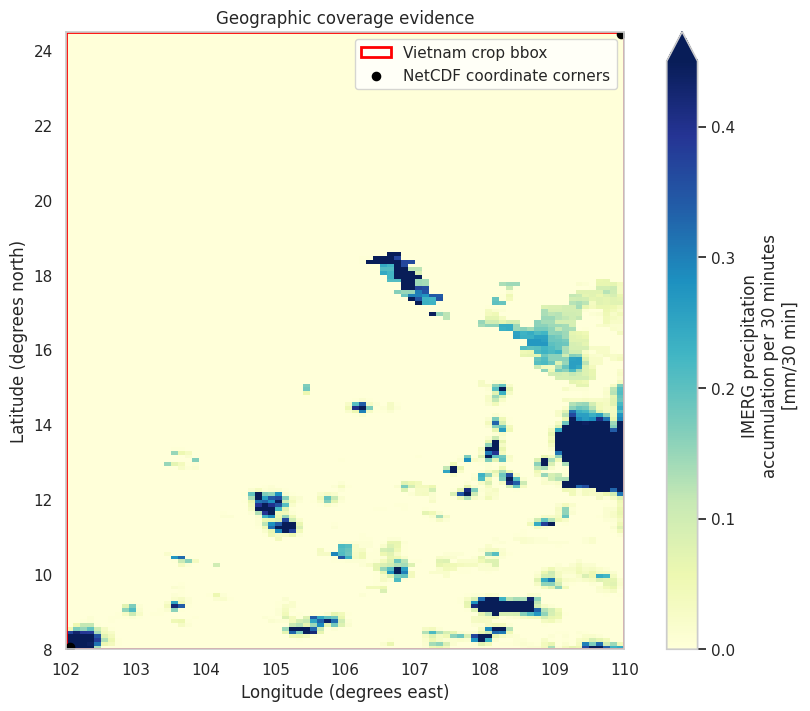

In [10]:
VN_BBOX = {
    "west": 102.0,
    "south": 8.0,
    "east": 110.0,
    "north": 24.5,
}

if "lat" not in rain.coords or "lon" not in rain.coords:
    raise ValueError(f"Không tìm thấy tọa độ lat/lon. Coordinates: {list(rain.coords)}")

latitudes = np.asarray(rain.lat.values)
longitudes = np.asarray(rain.lon.values)
observed_bounds = {
    "latitude_min": float(latitudes.min()),
    "latitude_max": float(latitudes.max()),
    "longitude_min": float(longitudes.min()),
    "longitude_max": float(longitudes.max()),
}

inside_bbox = (
    observed_bounds["latitude_min"] >= VN_BBOX["south"]
    and observed_bounds["latitude_max"] <= VN_BBOX["north"]
    and observed_bounds["longitude_min"] >= VN_BBOX["west"]
    and observed_bounds["longitude_max"] <= VN_BBOX["east"]
)

print("Requested Vietnam crop bbox:", VN_BBOX)
print("Observed NetCDF coordinate bounds:", observed_bounds)
print(f"All coordinates inside requested bbox: {inside_bbox}")
print(f"Latitude resolution: {np.median(np.abs(np.diff(latitudes))):.4f} degrees")
print(f"Longitude resolution: {np.median(np.abs(np.diff(longitudes))):.4f} degrees")
print("Four coordinate corners:")
print({
    "south_west": (observed_bounds["latitude_min"], observed_bounds["longitude_min"]),
    "north_west": (observed_bounds["latitude_max"], observed_bounds["longitude_min"]),
    "south_east": (observed_bounds["latitude_min"], observed_bounds["longitude_max"]),
    "north_east": (observed_bounds["latitude_max"], observed_bounds["longitude_max"]),
})

from matplotlib.patches import Rectangle

first_frame = rain.isel(time=0)
fig, axis = plt.subplots(figsize=(8, 7), constrained_layout=True)
first_frame.plot(ax=axis, cmap="YlGnBu", robust=True, add_colorbar=True)
axis.add_patch(Rectangle(
    (VN_BBOX["west"], VN_BBOX["south"]),
    VN_BBOX["east"] - VN_BBOX["west"],
    VN_BBOX["north"] - VN_BBOX["south"],
    fill=False,
    edgecolor="red",
    linewidth=2,
    label="Vietnam crop bbox",
))
axis.scatter(
    [observed_bounds["longitude_min"], observed_bounds["longitude_max"]],
    [observed_bounds["latitude_min"], observed_bounds["latitude_max"]],
    color="black",
    s=35,
    label="NetCDF coordinate corners",
)
axis.set_title("Geographic coverage evidence")
axis.set_xlabel("Longitude (degrees east)")
axis.set_ylabel("Latitude (degrees north)")
axis.legend(loc="best")
plt.savefig(FIG_DIR / "vietnam_coverage_evidence.png", dpi=160)
plt.show()

Grid pixels inside Vietnam polygon: 2,802
Grid pixels outside Vietnam polygon: 10,398
Vietnam pixel fraction: 21.23%


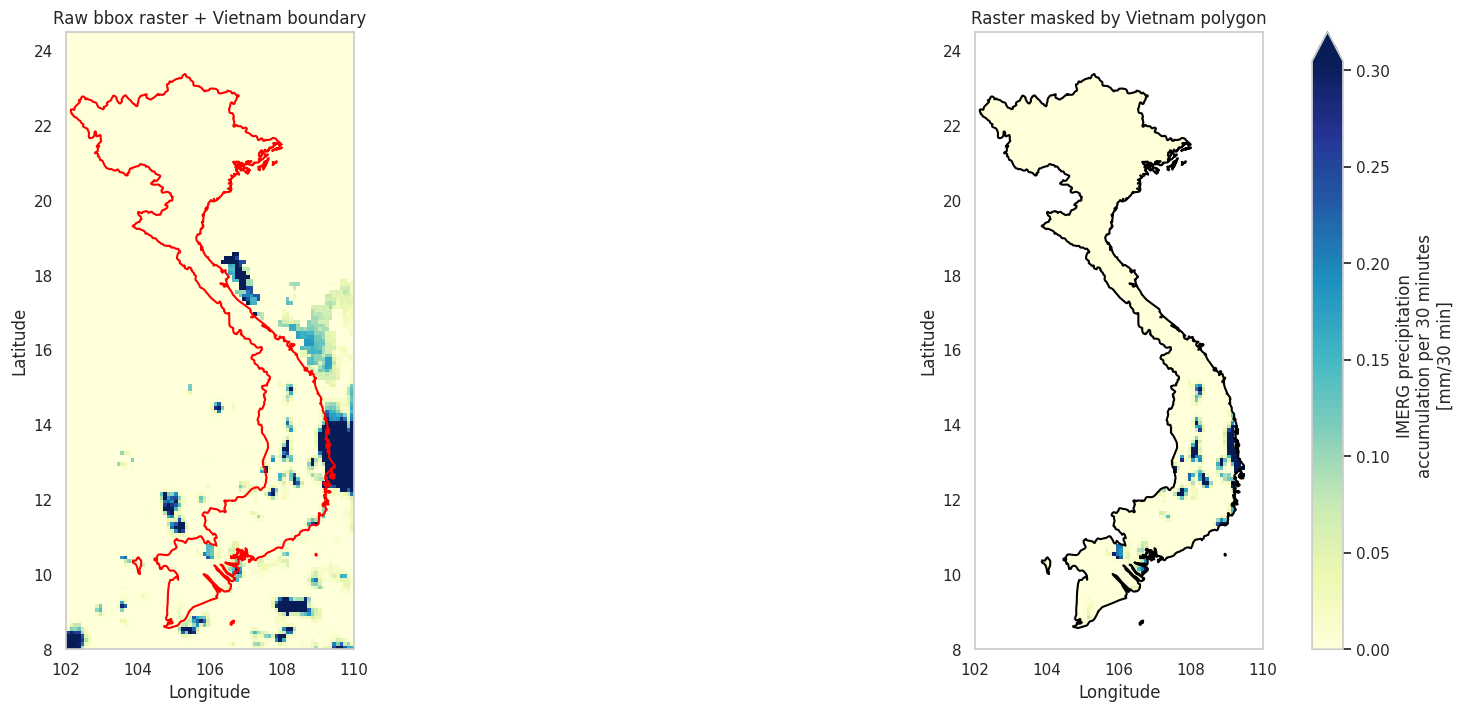

Saved polygon evidence map: /content/drive/MyDrive/Rainfall_Nowcasting/IMERG/figures_eda/rainfall_vietnam_polygon_evidence.png


In [11]:
if "google.colab" in sys.modules:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "geopandas", "shapely",
    ])

import geopandas as gpd

NATURAL_EARTH_URL = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip"
countries = gpd.read_file(NATURAL_EARTH_URL).to_crs("EPSG:4326")
name_column = "ADMIN" if "ADMIN" in countries.columns else "NAME_EN"
vietnam = countries[countries[name_column].astype(str).str.contains("viet", case=False, na=False)]
if vietnam.empty:
    raise ValueError("Không tìm thấy polygon Việt Nam trong Natural Earth dataset.")

latitudes = np.asarray(rain.lat.values)
longitudes = np.asarray(rain.lon.values)
longitude_grid, latitude_grid = np.meshgrid(longitudes, latitudes)
points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(longitude_grid.ravel(), latitude_grid.ravel()),
    crs="EPSG:4326",
)
joined = gpd.sjoin(
    points,
    vietnam[["geometry"]],
    how="left",
    predicate="within",
)
inside_mask = joined.index_right.notna().to_numpy().reshape(latitude_grid.shape)
inside_count = int(inside_mask.sum())
outside_count = int(inside_mask.size - inside_count)
print(f"Grid pixels inside Vietnam polygon: {inside_count:,}")
print(f"Grid pixels outside Vietnam polygon: {outside_count:,}")
print(f"Vietnam pixel fraction: {inside_count / inside_mask.size:.2%}")

polygon_mask = xr.DataArray(
    inside_mask,
    dims=("lat", "lon"),
    coords={"lat": rain.lat, "lon": rain.lon},
)
raw_frame = rain.isel(time=0)
vietnam_frame = raw_frame.where(polygon_mask)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
raw_frame.plot(ax=axes[0], cmap="YlGnBu", robust=True, add_colorbar=False)
vietnam.boundary.plot(ax=axes[0], color="red", linewidth=1.5)
axes[0].set_title("Raw bbox raster + Vietnam boundary")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

vietnam_frame.plot(ax=axes[1], cmap="YlGnBu", robust=True, add_colorbar=True)
vietnam.boundary.plot(ax=axes[1], color="black", linewidth=1.5)
axes[1].set_title("Raster masked by Vietnam polygon")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

polygon_map_path = FIG_DIR / "rainfall_vietnam_polygon_evidence.png"
plt.savefig(polygon_map_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved polygon evidence map: {polygon_map_path}")